In [454]:
import tmm
import numpy as np
import pyswarms as ps
from matplotlib import pyplot as plt
from importlib import reload
from scipy.interpolate import interp1d
plt=reload(plt)
from pyswarms.utils.functions import single_obj as fx
from pyswarms.utils.plotters import (plot_cost_history, plot_contour, plot_surface)
from pyswarms.utils.plotters.formatters import (Mesher, Designer)
from pathlib import Path
from os import path as pth

In [198]:
def obj_func(pos):
    obj = np.zeros(len(pos))
    for i,x in enumerate(pos):
        obj[i] = 4 - x**2
    return -obj

x = np.array([[-1], [-0.5], [0], [0.5], [1]])
print(len(x))
objs = obj_func(x)
print(objs)
print(objs.shape)

5
[-3.   -3.75 -4.   -3.75 -3.  ]
(5,)


In [200]:
N_layers = 10
def fom_func(pos):
    pol = 'p'
    lambda_list = np.linspace(2,5,100)
    delta_lamb = lambda_list[-1] - lambda_list[0]
    angle = 0
    obj = np.zeros(len(pos))

    # iterate over rows (particles) to populate obj array
    for i, x in enumerate(pos):
        d_list = np.empty(N_layers+2)
        n_list = np.empty(N_layers+2, dtype=complex)
        for j in range(N_layers):
            n = x[3*j]
            k = x[3*j+1]
            d = x[3*j+2]
            n_list[j+1] = n + 1j*k
            d_list[j+1] = d
        d_list[-1] = np.inf
        d_list[0] = np.inf 
        n_list[-1] = 1.7
        n_list[0] = 1.7
        T_list = np.zeros_like(lambda_list)
        R_list = np.zeros_like(lambda_list)
        A_list = np.zeros_like(lambda_list)
        for j, lamb in enumerate(lambda_list):
            T_list[j] = tmm.coh_tmm(pol, n_list, d_list, angle, lamb)['T']
            R_list[j] = tmm.coh_tmm(pol, n_list, d_list, angle, lamb)['R']
            A_list[j] = 1 - T_list[j] - R_list[j]
            
        obj[i] = (np.trapz(T_list, x=lambda_list))**2 / np.trapz(A_list, x=lambda_list) / delta_lamb

    return -obj

# calculate transmittance, reflectance, and emittance as a fn. of wavelength
def TRA_func(x):
    pol = 'p'
    lambda_list = np.linspace(2,5,100)
    delta_lamb = lambda_list[-1] - lambda_list[0]
    angle = 0
    d_list = np.empty(N_layers+2)
    n_list = np.empty(N_layers+2, dtype=complex)
    for j in range(N_layers):
        n = x[3*j]
        k = x[3*j+1]
        d = x[3*j+2]
        n_list[j+1] = n + 1j*k
        d_list[j+1] = d
    d_list[-1] = np.inf
    d_list[0] = np.inf 
    n_list[-1] = 1.7
    n_list[0] = 1.7
    T_list_LR = np.zeros_like(lambda_list)
    R_list_LR = np.zeros_like(lambda_list)
    A_list_LR = np.zeros_like(lambda_list)
    T_list_RL = np.zeros_like(lambda_list)
    R_list_RL = np.zeros_like(lambda_list)
    A_list_RL = np.zeros_like(lambda_list)
    for j, lamb in enumerate(lambda_list):
        T_list_LR[j] = tmm.coh_tmm(pol, n_list, d_list, angle, lamb)['T']
        R_list_LR[j] = tmm.coh_tmm(pol, n_list, d_list, angle, lamb)['R']
        A_list_LR[j] = 1 - T_list_LR[j] - R_list_LR[j]

        T_list_RL[j] = tmm.coh_tmm_reverse(pol, n_list, d_list, angle, lamb)['T']
        R_list_RL[j] = tmm.coh_tmm_reverse(pol, n_list, d_list, angle, lamb)['R']
        A_list_RL[j] = 1 - T_list_RL[j] - R_list_RL[j]

    return (T_list_LR, R_list_LR, A_list_LR, T_list_RL, R_list_RL, A_list_RL)
'''
x = np.array([[6.96784497e-02, 3.18333796e-01, 1.16550807e-01, 1.40288316e-01,
       9.48143890e-01, 8.51894687e-02, 1.56484598e+00, 4.55842963e+00,
       1.63517705e-03]])
obj_values = fom_func(x) 
print(obj_values)
'''

'\nx = np.array([[6.96784497e-02, 3.18333796e-01, 1.16550807e-01, 1.40288316e-01,\n       9.48143890e-01, 8.51894687e-02, 1.56484598e+00, 4.55842963e+00,\n       1.63517705e-03]])\nobj_values = fom_func(x) \nprint(obj_values)\n'

In [472]:
# Set-up hyperparameters
options = {'c1': 0.2, 'c2': 1.0, 'w':0.9}
bounds_min = np.zeros(3*N_layers)
bounds_max = np.zeros(3*N_layers)
for i in range(N_layers):
    bounds_min[3*i] = 1.3
    bounds_max[3*i] = 5
    bounds_min[3*i+1] = 0.01
    bounds_max[3*i+1] = 1
    bounds_min[3*i+2] = 0.01
    bounds_max[3*i+2] = 0.1
bounds = (bounds_min, bounds_max)
# Call instance of GlobalBestPSO
optimizer = ps.single.GlobalBestPSO(n_particles=1000, dimensions=3*N_layers,
                                    options=options, bounds=bounds, ftol=0.01, ftol_iter=25)

# Perform optimization
stats = optimizer.optimize(fom_func, iters=100)

2024-10-25 03:00:38,476 - pyswarms.single.global_best - INFO - Optimize for 100 iters with {'c1': 0.2, 'c2': 1.0, 'w': 0.9}
pyswarms.single.global_best:  43%|████████████████████████▉                                 |43/100, best_cost=-2.03
2024-10-25 03:36:43,551 - pyswarms.single.global_best - INFO - Optimization finished | best cost: -2.030644228213326, best pos: [4.86936434 0.27228133 0.01616527 3.93385222 0.08755313 0.05443708
 4.93478606 0.39172914 0.01427809 3.88456099 0.0782381  0.0531064
 4.69697015 0.26480832 0.01524141 2.22875024 0.02327041 0.03090529
 2.96506261 0.1737068  0.01744991 4.88491505 0.55130448 0.01030359
 2.92541209 0.21854325 0.01258994 3.83428153 0.24487468 0.01975187]


In [474]:
basepath = "C:\\Users\\kl89\\MS Window Project\\Swarm_Opt\\2024October23"
runname = "run3_c1-02_c2-10"
currpath = pth.join(basepath, runname)
Path(currpath).mkdir(parents=True, exist_ok=True)
np.set_printoptions(suppress=True)
#print(np.round(stats[1], decimals=4))
final_pos = stats[1]
final_obj = round(stats[0], 2)
np.savetxt(pth.join(currpath, 'final_particle.txt'), final_pos, delimiter=' ')
d_list = np.empty(N_layers + 1)
n_list = np.empty(N_layers + 1, dtype=complex)

total_thickness = 0
for j in range(N_layers):
    n = final_pos[3*j]
    k = final_pos[3*j+1]
    d = final_pos[3*j+2]
    n_list[j+1] = n + 1j*k
    print(f"d at layer {j} is {np.round(d, 5)}")
    d_list[j+1] = d + total_thickness
    total_thickness = d_list[j+1]

d_list[0] = 0
n_list[0] = 1.7

np.savetxt(pth.join(currpath, 'layer_positions.txt'), d_list, delimiter=' ')
np.savetxt(pth.join(currpath, 'layer_RI.txt'), n_list, delimiter=' ')

print(f"n values: {np.real(n_list)}")
print(f"k values: {np.imag(n_list)}")
print(f"d values: {np.round(d_list, 5)}")

(T_list_LR, R_list_LR, A_list_LR, T_list_RL, R_list_RL, A_list_RL) = TRA_func(final_pos)
lambda_list = np.linspace(2,5,100)
delta_lamb = lambda_list[-1] - lambda_list[0]

losses_total = np.trapz(np.imag(n_list), x=d_list)
k_bulk = np.zeros(len(d_list)+2)
k_bulk += losses_total/(d_list[-1]-d_list[0])
k_bulk[0] = k_bulk[1] = k_bulk[-1] = 0
n_bulk = np.zeros(len(d_list)+2)
n_bulk += 1.7
trans_bulk = np.exp(-4*np.pi*losses_total/lambda_list)
emiss_bulk = 1 - trans_bulk

FOM_bulk = -round((np.trapz(trans_bulk, x=lambda_list))**2 / np.trapz(emiss_bulk, x=lambda_list) / delta_lamb, 2)
np.savetxt(pth.join(currpath, 'FOM_MSandBulk.txt'), [final_obj, FOM_bulk], delimiter=' ')
print(f'FOM_bulk is: {FOM_bulk}')

d at layer 0 is 0.01617
d at layer 1 is 0.05444
d at layer 2 is 0.01428
d at layer 3 is 0.05311
d at layer 4 is 0.01524
d at layer 5 is 0.03091
d at layer 6 is 0.01745
d at layer 7 is 0.0103
d at layer 8 is 0.01259
d at layer 9 is 0.01975
n values: [1.7        4.86936434 3.93385222 4.93478606 3.88456099 4.69697015
 2.22875024 2.96506261 4.88491505 2.92541209 3.83428153]
k values: [0.         0.27228133 0.08755313 0.39172914 0.0782381  0.26480832
 0.02327041 0.1737068  0.55130448 0.21854325 0.24487468]
d values: [0.      0.01617 0.0706  0.08488 0.13799 0.15323 0.18413 0.20158 0.21189
 0.22448 0.24423]
FOM_bulk is: -3.95


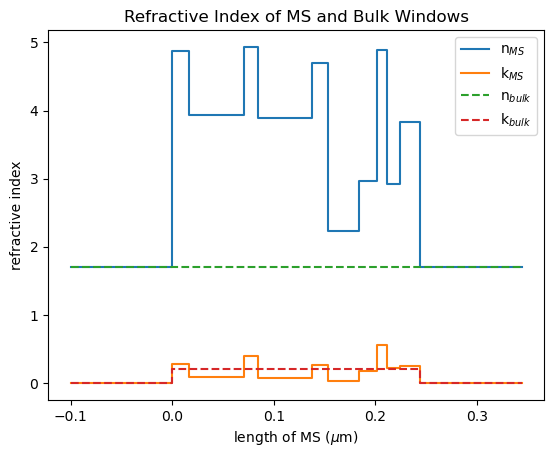

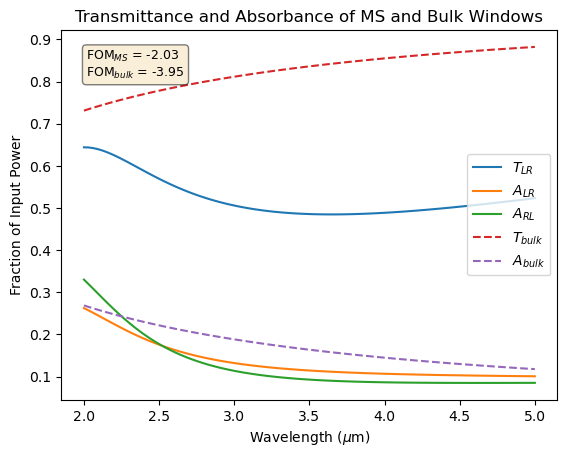

In [476]:
n_list_plot = np.concatenate(([1.7], n_list, [1.7]))
d_list_plot = np.concatenate(([-0.1], d_list, [0.1+d_list[-1]]))

plt.figure()
plt.step(d_list_plot, np.real(n_list_plot), label='n$_{MS}$')
plt.step(d_list_plot, np.imag(n_list_plot), label='k$_{MS}$')
plt.plot(d_list_plot, n_bulk, '--', label='n$_{bulk}$')
plt.step(d_list_plot, k_bulk, '--', label='k$_{bulk}$')
plt.legend(loc='upper right')
plt.title(f"Refractive Index of MS and Bulk Windows")
plt.xlabel('length of MS ($\mu$m)')
plt.ylabel('refractive index')
plt.savefig(pth.join(currpath,'RI_plot.png'))
plt.show()

plt.figure()
ax = plt.gca()
plt.plot(lambda_list, T_list_LR, label='$T_{LR}$')
plt.plot(lambda_list, A_list_LR, label='$A_{LR}$')
plt.plot(lambda_list, A_list_RL, label='$A_{RL}$')
plt.plot(lambda_list, trans_bulk, '--', label='$T_{bulk}$')
plt.plot(lambda_list, emiss_bulk, '--', label='$A_{bulk}$')
textstr = f"FOM$_{{MS}}$ = {final_obj}\nFOM$_{{bulk}}$ = {FOM_bulk}"
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
plt.text(0.05, 0.95, textstr, fontsize=9, transform=ax.transAxes,
        verticalalignment='top', bbox=props)
plt.xlabel('Wavelength ($\mu$m)')
plt.ylabel('Fraction of Input Power')
plt.title('Transmittance and Absorbance of MS and Bulk Windows')
plt.legend(loc='center right')
plt.savefig(pth.join(currpath, 'Trans_Absorp.png'))

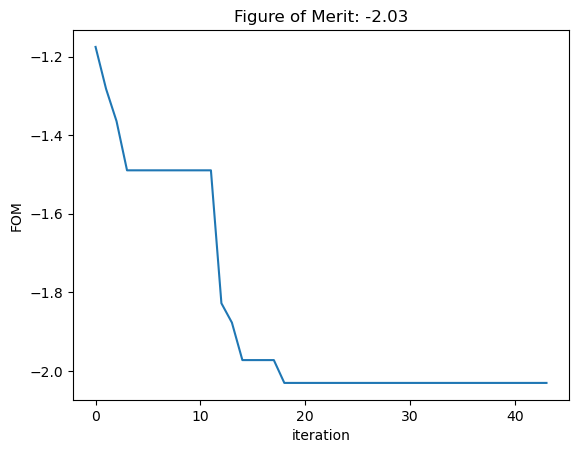

"\nm = Mesher(func=fom_func)\n\n# Make animation\nanimation = plot_contour(pos_history=optimizer.pos_history,\n                         mesher=m,\n                         mark=(0,0))\nanimation.save('plot0.gif')\n#Image(url='plot0.gif')\n"

In [478]:
#plot_cost_history(cost_history=optimizer.cost_history) OR plot_cost_history(cost_history)
#plt.show()

plt.figure()
cost_history = optimizer.cost_history
num_iterations = len(cost_history)
plt.plot(range(num_iterations), cost_history)
plt.title(f'Figure of Merit: {final_obj}')
plt.ylabel('FOM')
plt.xlabel('iteration')
plt.savefig(pth.join(currpath, 'FOM.png'))
plt.show()

'''
m = Mesher(func=fom_func)

# Make animation
animation = plot_contour(pos_history=optimizer.pos_history,
                         mesher=m,
                         mark=(0,0))
animation.save('plot0.gif')
#Image(url='plot0.gif')
'''

[0.00245962 0.12769854 0.04201948 0.44609196 0.16187961 0.14012006
 0.02208302 0.10987358 0.2965368  0.25977682]
changed ax!


2024-10-15 20:58:36,022 - matplotlib.animation - INFO - Animation.save using <class 'matplotlib.animation.FFMpegWriter'>
2024-10-15 20:58:36,023 - matplotlib.animation - INFO - MovieWriter._run: running command: ffmpeg -f rawvideo -vcodec rawvideo -s 1000x800 -pix_fmt rgba -r 12.5 -loglevel error -i pipe: -filter_complex 'split [a][b];[a] palettegen [p];[b][p] paletteuse' -y plot1.gif


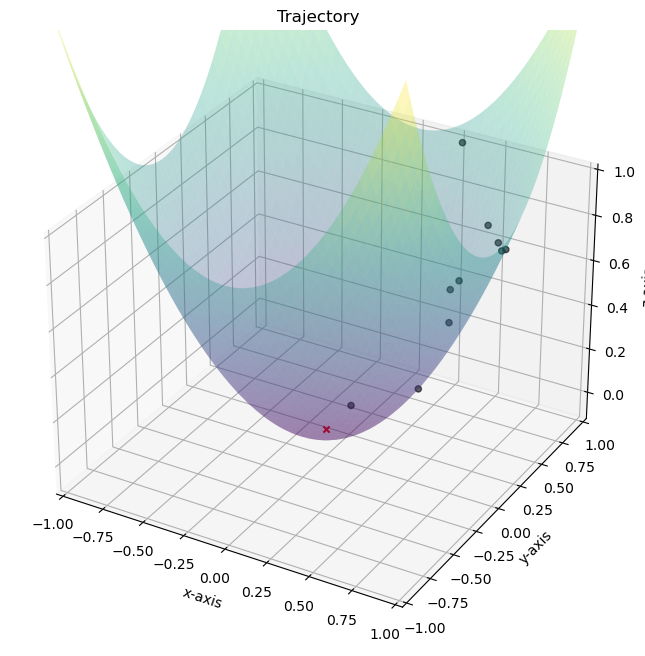

In [6]:
pos_history_3d = m.compute_history_3d(optimizer.pos_history)
print(pos_history_3d[5,:,2])
d = Designer(limits=[(-1,1), (-1,1), (-0.1,1)], label=['x-axis', 'y-axis', 'z-axis'])
'''
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(pos_history_3d[:,0, 0], pos_history_3d[:,0, 1], pos_history_3d[:,0, 2])
plt.show()
'''

animation3d = plot_surface(pos_history=pos_history_3d, # Use the cost_history we computed
                           mesher=m, designer=d,       # Customizations
                           mark=(0,0,0))               # Mark minima

animation3d.save('plot1.gif')

In [7]:
x = np.empty((3,2))
x[0] = [2, 2]
x[1] = [-2, 3]
x[2] = [1, 5]
print(x)
y = (x**2)
print(y)
z = np.sum(y, axis=1)
print(z)
sphere_func = fx.sphere(x)
print(sphere_func.shape)

[[ 2.  2.]
 [-2.  3.]
 [ 1.  5.]]
[[ 4.  4.]
 [ 4.  9.]
 [ 1. 25.]]
[ 8. 13. 26.]
(3,)


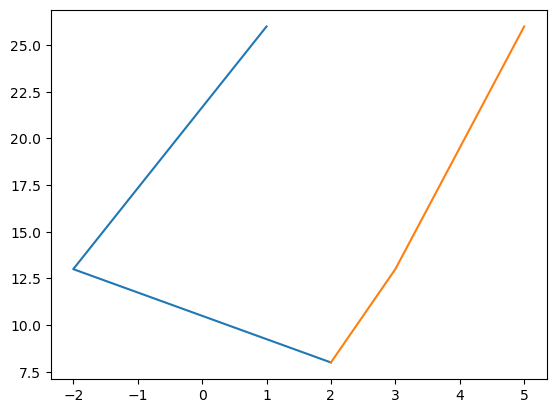

In [8]:
plt.plot(x, sphere_func)